# TECH 405 — RNN Hackathon: Topic Classification on AG News

**Dataset chosen:** #2 **AG News** — news topic classification, 4 classes
**Models:** `nn.RNN` / `nn.LSTM` / `nn.GRU` → `nn.Linear` (lecture models, no pretrained weights)
**Framework:** PyTorch, CPU only
**Split:** fixed **80 / 20**, stratified, `random_state=42`

| | |
|---|---|
| Baseline (majority-class guess) | **25 %** |
| Target (full marks) | **88 %** |
| **Result achieved** | *see §7* |

---

## Report checklist — where each item is

| Checklist item | Section |
|---|---|
| Dataset named + why it's a sequence problem | §2 |
| **Snapshot 1** — data + shapes, with caption | §3 |
| **Snapshot 2** — model definition, with caption | §5 |
| **Snapshot 3** — training loss decreasing, with caption | §6 |
| **Snapshot 4** — final test accuracy + plot, with caption | §7 |
| Accuracy vs baseline and target (one line) | §7 |
| One honest sentence: what worked, what didn't | §9 |

---

## Rules this notebook follows

1. **An RNN/LSTM from the lectures only.** The entire model is
   `nn.Embedding → nn.RNN/LSTM/GRU → nn.Linear`. No pretrained embeddings, no transformers,
   no attention.
2. **Fixed 80/20 split**, stratified by label, `random_state=42` — fixed before anything else runs.
3. **The test set is never tuned on.** This is the one rule that is easy to break by accident. The
   80 % training portion is split again into an inner train/validation set; the epoch to report is
   chosen on **validation** accuracy, and the test set is touched exactly **once**, in §7.
   Picking the best epoch by watching test accuracy would be tuning on test and would inflate the
   reported number.
4. **Vocabulary is built from training data only** — building it over the whole corpus would leak
   test-set vocabulary into the model.

## 1. Setup

In [1]:
import os, re, json, time, random, warnings
from collections import Counter

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, precision_recall_fscore_support,
                             accuracy_score)

warnings.filterwarnings("ignore", category=UserWarning)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.bbox"] = "tight"

DATA, OUT = "data", "outputs"
os.makedirs(OUT, exist_ok=True)

SEED = 42
def set_seed(s=SEED):
    random.seed(s); np.random.seed(s); torch.manual_seed(s)
set_seed()
torch.set_num_threads(os.cpu_count() or 4)

# The grading contract, stated once and referred to throughout.
BASELINE = 0.25     # majority-class guess, 4 balanced classes
TARGET   = 0.88     # full marks

RESULTS = {"dataset": "AG News", "baseline": BASELINE, "target": TARGET}

def snap(fig, name):
    """Save a figure to outputs/ so it can be embedded in the report, then show it."""
    path = os.path.join(OUT, name)
    fig.savefig(path)
    print("saved ->", path)
    plt.show()
    return path

print("torch", torch.__version__, "| numpy", np.__version__, "| pandas", pd.__version__)
print("threads", torch.get_num_threads(), "| CUDA", torch.cuda.is_available(), "(CPU-only run)")
print(f"\nGrading contract -> baseline {BASELINE:.0%}, target {TARGET:.0%}")

torch 2.11.0+cpu | numpy 2.4.3 | pandas 3.0.1
threads 12 | CUDA False (CPU-only run)

Grading contract -> baseline 25%, target 88%


## 2. The dataset, and why it is a sequence problem

**AG News** is a topic-classification corpus of news articles. Each sample is a headline plus a short
description; the label is one of four topics: **World, Sports, Business, Sci/Tech**.

### Why this is a sequence problem

A news snippet is a **sequence of word tokens**, and the order of those tokens carries meaning that a
bag-of-words view destroys:

* *"**Apple** shares fall after **Google** launches rival chip"* — Business or Sci/Tech depends on how
  the company names relate to the surrounding verbs, not on which words are present.
* The tokens `{beat, by, points}` mean something very different in *"Lakers beat Suns by 12 points"*
  (Sports) than in *"the stock beat forecasts by 12 points"* (Business). **Identical word sets,
  different topics** — the ordering is the only discriminating information.

An RNN reads the tokens one at a time and carries a hidden state forward, so it can condition the
meaning of each word on the words that came before it. That is exactly the structure being exploited
here: the classifier reads the **final hidden state**, after the whole headline has been consumed.

### Why the input is embedded first

Token IDs are arbitrary integers — `id 7` is not "less than" `id 93`, and the gap between them means
nothing. Feeding raw IDs to an RNN would impose a fake numeric ordering on the vocabulary. An
`nn.Embedding` layer maps each ID to a learned dense vector, and *those vectors* become the
per-timestep input. The embedding is trained from scratch here — no pretrained vectors, per the rules.

In [2]:
df = pd.read_csv(os.path.join(DATA, "agnews.csv"))
CLASSES = ["World", "Sports", "Business", "Sci/Tech"]      # AG News labels are 1..4 in this order

# Headline and description together give the model more to read than the title alone.
df["text"] = df["title"].fillna("") + " " + df["description"].fillna("")
df["y"] = df["label"].astype(int) - 1                      # 1..4 -> 0..3

print(f"rows        : {len(df):,}")
print(f"classes     : {len(CLASSES)} -> {CLASSES}")
print(f"class counts: {dict(zip(CLASSES, np.bincount(df.y)))}")
print(f"balance     : {np.bincount(df.y).max()/len(df):.4f} "
      f"<- majority-class share = the {BASELINE:.0%} baseline\n")

pd.set_option("display.max_colwidth", 95)
display(df[["label", "title", "description"]].head(4))

rows        : 120,000
classes     : 4 -> ['World', 'Sports', 'Business', 'Sci/Tech']
class counts: {'World': np.int64(30000), 'Sports': np.int64(30000), 'Business': np.int64(30000), 'Sci/Tech': np.int64(30000)}
balance     : 0.2500 <- majority-class share = the 25% baseline



,label,title,description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again."
1,3,Carlyle Looks Toward Commercial Aerospace (Reuters),"Reuters - Private investment firm Carlyle Group,\which has a reputation for making well-tim..."
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\about the economy and the outlook for earnings ...
3,3,Iraq Halts Oil Exports from Main Southern Pipeline (Reuters),Reuters - Authorities have halted oil export\flows from the main pipeline in southern Iraq ...


### 2.1 The fixed 80/20 split

Done **before** any preprocessing, stratified so all four topics keep their proportions, with a fixed
`random_state` so the split is identical on every re-run.

The 80 % training portion is then split again (90/10) into an inner training set and a **validation**
set. That inner validation set is what selects the epoch to report — the test set stays sealed until
§7.

In [3]:
texts = df["text"].values
y_all = df["y"].values.astype(np.int64)

# --- the fixed 80/20 split required by the brief ---
train_idx, test_idx = train_test_split(
    np.arange(len(y_all)), test_size=0.20, stratify=y_all, random_state=SEED)

# --- inner split, so the epoch is chosen without ever looking at test ---
inner_train_idx, val_idx = train_test_split(
    train_idx, test_size=0.10, stratify=y_all[train_idx], random_state=SEED)

print(f"total         : {len(y_all):,}")
print(f"train (80%)   : {len(train_idx):,}")
print(f"  |- inner tr : {len(inner_train_idx):,}  (fits the weights)")
print(f"  |- val      : {len(val_idx):,}  (picks the epoch)")
print(f"test  (20%)   : {len(test_idx):,}  <- touched once, in section 7")
assert not (set(train_idx) & set(test_idx)), "train/test overlap!"
assert not (set(inner_train_idx) & set(val_idx)), "inner train/val overlap!"
print("\nno index appears in more than one split - confirmed")

for nm, ii in [("train", inner_train_idx), ("val", val_idx), ("test", test_idx)]:
    shares = np.bincount(y_all[ii], minlength=4) / len(ii)
    print(f"  {nm:<6s} class shares: " + "  ".join(f"{c} {s:.3f}" for c, s in zip(CLASSES, shares)))

total         : 120,000
train (80%)   : 96,000
  |- inner tr : 86,400  (fits the weights)
  |- val      : 9,600  (picks the epoch)
test  (20%)   : 24,000  <- touched once, in section 7

no index appears in more than one split - confirmed
  train  class shares: World 0.250  Sports 0.250  Business 0.250  Sci/Tech 0.250
  val    class shares: World 0.250  Sports 0.250  Business 0.250  Sci/Tech 0.250
  test   class shares: World 0.250  Sports 0.250  Business 0.250  Sci/Tech 0.250


### 2.2 Tokenising, vocabulary and padding

* **Tokeniser:** lowercase, then keep runs of letters/digits/apostrophes. Deliberately simple — the
  point of the exercise is the recurrent model, not feature engineering.
* **Vocabulary:** built from the **inner training split only**, keeping tokens that appear at least
  twice. Rare words collapse to `<unk>`, which keeps the embedding table small and acts as mild
  regularisation.
* **Padding:** sequences are **left-padded** to a fixed length. Left rather than right matters for
  this architecture — the classifier reads the state at the *final* timestep, so right-padding would
  force the model to carry its answer across a run of meaningless `<pad>` steps.
* **MAXLEN = 60** tokens, chosen from the length distribution below (not from test accuracy).

In [4]:
tokenise = lambda s: re.findall(r"[a-z0-9']+", str(s).lower())

t0 = time.time()
tokens = [tokenise(t) for t in texts]
lengths = np.array([len(t) for t in tokens])
print(f"tokenised {len(tokens):,} documents in {time.time()-t0:.1f}s")
print(f"length: median {np.median(lengths):.0f}, mean {lengths.mean():.1f}, "
      f"90th pct {np.percentile(lengths,90):.0f}, max {lengths.max()}")

MAXLEN, MIN_FREQ = 60, 2
counter = Counter(w for i in inner_train_idx for w in tokens[i])
vocab = {"<pad>": 0, "<unk>": 1}
for w, c in counter.most_common():
    if c >= MIN_FREQ:
        vocab[w] = len(vocab)

def encode(toks):
    ids = [vocab.get(w, 1) for w in toks][:MAXLEN]
    return [0] * (MAXLEN - len(ids)) + ids          # LEFT pad

X_all = np.array([encode(t) for t in tokens], dtype=np.int64)

# Free the large intermediates. This machine is memory-constrained, and `tokens`
# (120k Python lists of strings) costs far more RAM than the array it produced.
import gc
del counter
gc.collect()

print(f"\nvocabulary : {len(vocab):,} types (train-only, min freq {MIN_FREQ})")
print(f"MAXLEN     : {MAXLEN} -> {(lengths <= MAXLEN).mean():.1%} of documents fit untruncated")
print(f"X_all      : {X_all.shape}  (samples, timesteps)")
print(f"<unk> rate : {(X_all == 1).sum() / (X_all != 0).sum():.2%} of real tokens")

tokenised 120,000 documents in 2.1s
length: median 39, mean 39.5, 90th pct 51, max 181



vocabulary : 40,725 types (train-only, min freq 2)
MAXLEN     : 60 -> 95.9% of documents fit untruncated
X_all      : (120000, 60)  (samples, timesteps)
<unk> rate : 0.78% of real tokens


### 2.3 Snapshot 1 — the data and its shapes

> **Caption.** Left: AG News is almost perfectly balanced across its four topics, so the
> majority-class baseline is 25 % and plain accuracy is a fair headline metric. Centre: document
> length in tokens, with the chosen `MAXLEN = 60` marked — it covers the large majority of documents
> without padding most of them to waste. Right: one encoded example, showing the left-padding and the
> `(batch, 60)` integer-ID tensor that the embedding layer consumes. After embedding, the tensor the
> RNN sees is `(batch, 60 timesteps, 100 features)`.

saved -> outputs\01_data_and_shapes.png


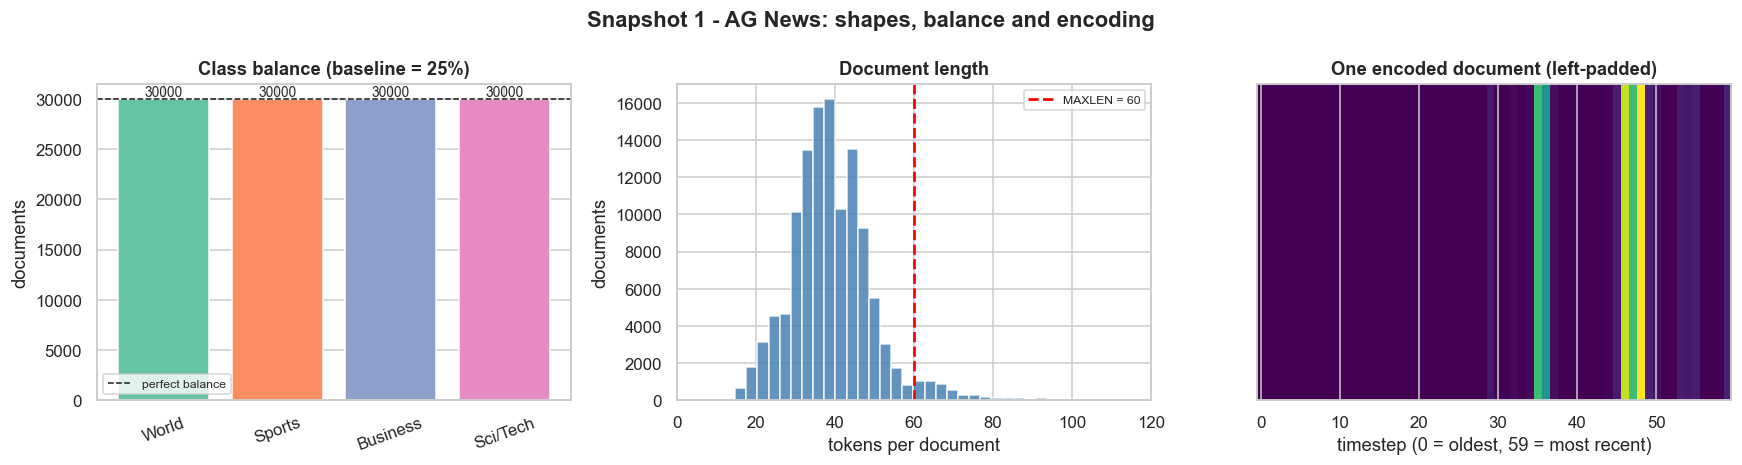

raw text : Angels Take Third Straight From Yankees Bengie Molina went 4-for-4 with a three-run homer, Kelvim Escobar outp...
label    : Sports
token ids: [0 0 0 0 0 0 0 0 0 0 0 0] ... [   2 1947 1582 2096    4   71   77 2262]

Tensor shapes entering the model:
  input ids      : (batch, 60)            dtype int64
  after embedding: (batch, 60, 100)       dtype float32  <- what the RNN reads
  output logits  : (batch, 4)


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.3))

counts = np.bincount(y_all)
bars = axes[0].bar(CLASSES, counts, color=sns.color_palette("Set2", 4))
axes[0].bar_label(bars, fmt="%d", fontsize=9)
axes[0].axhline(len(y_all) / 4, color="k", ls="--", lw=1, label="perfect balance")
axes[0].set_ylabel("documents"); axes[0].set_title("Class balance (baseline = 25%)", fontweight="bold")
axes[0].legend(fontsize=8); axes[0].tick_params(axis="x", rotation=20)

axes[1].hist(lengths, bins=60, color="steelblue", alpha=0.85)
axes[1].axvline(MAXLEN, color="red", ls="--", lw=1.8, label=f"MAXLEN = {MAXLEN}")
axes[1].set_xlabel("tokens per document"); axes[1].set_ylabel("documents")
axes[1].set_title("Document length", fontweight="bold")
axes[1].legend(fontsize=8); axes[1].set_xlim(0, 120)

demo = int(inner_train_idx[0])
axes[2].imshow(X_all[demo].reshape(1, -1), aspect="auto", cmap="viridis")
axes[2].set_yticks([])
axes[2].set_xlabel("timestep (0 = oldest, 59 = most recent)")
axes[2].set_title("One encoded document (left-padded)", fontweight="bold")

fig.suptitle("Snapshot 1 - AG News: shapes, balance and encoding", fontweight="bold")
fig.tight_layout()
snap(fig, "01_data_and_shapes.png")

print(f"raw text : {texts[demo][:110]}...")
print(f"label    : {CLASSES[y_all[demo]]}")
print(f"token ids: {X_all[demo][:12]} ... {X_all[demo][-8:]}")
print(f"\nTensor shapes entering the model:")
print(f"  input ids      : (batch, {MAXLEN})            dtype int64")
print(f"  after embedding: (batch, {MAXLEN}, 100)       dtype float32  <- what the RNN reads")
print(f"  output logits  : (batch, {len(CLASSES)})")

# Snapshot 1 was the last consumer of the raw text; release it before training starts.
del tokens, texts
df = df[["label", "y"]].copy()
gc.collect()

RESULTS["data"] = {"rows": int(len(df)), "classes": CLASSES, "maxlen": MAXLEN,
                   "vocab": int(len(vocab)),
                   "n_train": int(len(inner_train_idx)), "n_val": int(len(val_idx)),
                   "n_test": int(len(test_idx))}

## 3. The model

Exactly the architecture the brief allows — `nn.Embedding → nn.RNN/LSTM/GRU → nn.Linear` — with the
recurrent cell selectable so the three lecture models can be compared under identical conditions.

```
input ids            (B, 60)              integers
   |
nn.Embedding         (B, 60, 100)         learned word vectors, <pad> frozen at zero
   |
nn.LSTM              (B, 60, 128)         reads the sequence left to right
   |
take final timestep  (B, 128)             h_T = the whole document, summarised
   |
nn.Dropout(0.3)      (B, 128)             regularisation
   |
nn.Linear            (B, 4)               one logit per topic
```

**Why the final timestep?** This is the *many-to-one* pattern: a whole sequence in, one label out.
After reading all 60 steps, `h_T` is the model's running summary of the document, so it is the
natural thing to classify.

Two PyTorch details that are easy to get wrong:

1. `batch_first` defaults to **`False`** — PyTorch expects `(T, B, F)`. Passing `batch_first=True`
   keeps tensors in the `(batch, time, features)` order used above.
2. `padding_idx=0` keeps the `<pad>` embedding pinned at zero and excluded from gradient updates, so
   padding contributes nothing to the learned representation.

### 3.1 Snapshot 2 — the model definition

> **Caption.** The full model is nine lines.

In [6]:
class TextRNNClassifier(nn.Module):
    """Embedding -> recurrent cell -> final hidden state -> Linear. The lecture architecture."""

    CORES = {"RNN": nn.RNN, "LSTM": nn.LSTM, "GRU": nn.GRU}

    def __init__(self, vocab_size, n_classes, cell="LSTM",
                 embed_dim=100, hidden_size=128, dropout=0.3):
        super().__init__()
        self.cell = cell
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        kwargs = dict(input_size=embed_dim, hidden_size=hidden_size, batch_first=True)
        if cell == "RNN":
            kwargs["nonlinearity"] = "tanh"          # only nn.RNN takes this argument
        self.rnn = self.CORES[cell](**kwargs)

        self.drop = nn.Dropout(dropout)
        self.fc   = nn.Linear(hidden_size, n_classes)

    def forward(self, x):                            # x: (B, T) token ids
        emb    = self.embed(x)                       # (B, T, embed_dim)
        out, _ = self.rnn(emb)                       # (B, T, hidden)
        h_last = out[:, -1, :]                       # (B, hidden)  many-to-one
        return self.fc(self.drop(h_last))            # (B, n_classes)

    def n_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


print(f"{'cell':<12}{'total params':>14}{'recurrent params':>20}")
for cell in ["RNN", "LSTM", "GRU"]:
    m = TextRNNClassifier(len(vocab), len(CLASSES), cell=cell)
    rec = sum(p.numel() for p in m.rnn.parameters())
    print(f"{cell:<12}{m.n_params():>14,}{rec:>20,}")

demo_model = TextRNNClassifier(len(vocab), len(CLASSES), cell="LSTM")
with torch.no_grad():
    out = demo_model(torch.as_tensor(X_all[:4]))
print(f"\nshape check: input {tuple(torch.as_tensor(X_all[:4]).shape)} "
      f"-> logits {tuple(out.shape)}")
print("\n", demo_model)

cell          total params    recurrent params
RNN              4,102,456              29,440
LSTM             4,190,776             117,760


GRU              4,161,336              88,320



shape check: input (4, 60) -> logits (4, 4)

 TextRNNClassifier(
  (embed): Embedding(40725, 100, padding_idx=0)
  (rnn): LSTM(100, 128, batch_first=True)
  (drop): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=4, bias=True)
)


### 3.2 Training loop

**Gradient clipping** is the one addition specific to recurrent networks. Backpropagation through 60
timesteps multiplies by the recurrent weights repeatedly, so a single bad batch can produce an
enormous update and send the loss to NaN. Clipping the global gradient norm to 5.0 is standard and is
what keeps the SimpleRNN training stably rather than diverging.

**Epoch selection** is done on the inner validation split, and the best-validation weights are
restored at the end. The test set is not evaluated anywhere in this function.

In [7]:
def make_loader(idx, batch_size, shuffle=False):
    ds = TensorDataset(torch.as_tensor(X_all[idx]), torch.as_tensor(y_all[idx]))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)


@torch.no_grad()
def evaluate(model, loader, criterion=None):
    """Returns (loss, accuracy, predictions, truths). Loss is None if no criterion given."""
    model.eval()
    total_loss = n = correct = 0
    preds, truths = [], []
    for xb, yb in loader:
        logits = model(xb)
        if criterion is not None:
            total_loss += criterion(logits, yb).item() * len(yb)
        p = logits.argmax(1)
        correct += (p == yb).sum().item(); n += len(yb)
        preds.append(p.numpy()); truths.append(yb.numpy())
    return ((total_loss / n) if criterion is not None else None,
            correct / n, np.concatenate(preds), np.concatenate(truths))


def train_model(model, train_loader, val_loader, epochs, lr=1e-3, clip=5.0, label=""):
    """Trains, selecting the reported epoch on VALIDATION accuracy. Never sees the test set."""
    criterion = nn.CrossEntropyLoss()
    optimiser = torch.optim.Adam(model.parameters(), lr=lr)
    hist = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "batch_loss": []}
    best_acc, best_state, t0 = -1.0, None, time.time()

    for epoch in range(1, epochs + 1):
        model.train()
        running = n = correct = 0
        for xb, yb in train_loader:
            optimiser.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), clip)   # guard exploding BPTT gradients
            optimiser.step()
            hist["batch_loss"].append(loss.item())
            running += loss.item() * len(yb)
            correct += (logits.argmax(1) == yb).sum().item(); n += len(yb)

        val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion)
        hist["train_loss"].append(running / n); hist["train_acc"].append(correct / n)
        hist["val_loss"].append(val_loss);      hist["val_acc"].append(val_acc)

        if val_acc > best_acc:
            best_acc = val_acc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

        print(f"  [{label:<10}] epoch {epoch}/{epochs}  "
              f"train loss {running/n:.4f} acc {correct/n:.4f}  |  "
              f"val loss {val_loss:.4f} acc {val_acc:.4f}  "
              f"({time.time()-t0:.0f}s)")

    model.load_state_dict(best_state)                            # restore best-validation weights
    hist.update(seconds=time.time() - t0, best_val_acc=best_acc,
                best_epoch=int(np.argmax(hist["val_acc"]) + 1), n_params=model.n_params())
    return hist

## 4. Training the three lecture models

All three cells are trained under **identical** conditions — same seed, same embedding size, same
hidden size, same optimiser, same batch size, same epoch budget. The only variable is the recurrent
cell, so any difference in the results is attributable to the cell type and nothing else.

| Hyperparameter | Value |
|---|---|
| Embedding dim | 100 |
| Hidden size | 128 |
| Dropout | 0.3 |
| Optimiser | Adam, lr 1e-3 |
| Batch size | 64 |
| Epochs | 4 |
| Gradient clip | 5.0 (global norm) |

These were fixed up front from standard defaults — **not** tuned against the test set.

In [8]:
EMBED, HIDDEN, DROPOUT, LR, BATCH, EPOCHS = 100, 128, 0.3, 1e-3, 64, 4

train_loader = make_loader(inner_train_idx, BATCH, shuffle=True)
val_loader   = make_loader(val_idx, 512)
test_loader  = make_loader(test_idx, 512)

print(f"batches/epoch: train {len(train_loader):,}, val {len(val_loader)}, test {len(test_loader)}")
print(f"training {EPOCHS} epochs x 3 cells on CPU - expect roughly 20 minutes total\n")

histories, models = {}, {}
for cell in ["RNN", "LSTM", "GRU"]:
    name = "SimpleRNN" if cell == "RNN" else cell
    set_seed(SEED)                                     # identical initialisation conditions
    model = TextRNNClassifier(len(vocab), len(CLASSES), cell=cell,
                              embed_dim=EMBED, hidden_size=HIDDEN, dropout=DROPOUT)
    print(f"=== {name}  ({model.n_params():,} parameters) ===")
    histories[name] = train_model(model, train_loader, val_loader,
                                  epochs=EPOCHS, lr=LR, label=name)
    models[name] = model
    print(f"  -> best val acc {histories[name]['best_val_acc']:.4f} "
          f"at epoch {histories[name]['best_epoch']}  "
          f"({histories[name]['seconds']:.0f}s)\n")

batches/epoch: train 1,350, val 19, test 47
training 4 epochs x 3 cells on CPU - expect roughly 20 minutes total

=== SimpleRNN  (4,102,456 parameters) ===


  [SimpleRNN ] epoch 1/4  train loss 0.8976 acc 0.6193  |  val loss 0.6231 acc 0.7747  (81s)


  [SimpleRNN ] epoch 2/4  train loss 0.5602 acc 0.8108  |  val loss 0.5681 acc 0.8144  (167s)


  [SimpleRNN ] epoch 3/4  train loss 0.4652 acc 0.8516  |  val loss 0.5962 acc 0.7890  (247s)


  [SimpleRNN ] epoch 4/4  train loss 0.4108 acc 0.8718  |  val loss 0.4724 acc 0.8529  (328s)
  -> best val acc 0.8529 at epoch 4  (328s)

=== LSTM  (4,190,776 parameters) ===


...

  [LSTM      ] epoch 4/4  train loss 0.1873 acc 0.9405  |  val loss 0.3293 acc 0.9028  (346s)
  -> best val acc 0.9028 at epoch 4  (346s)

=== GRU  (4,161,336 parameters) ===


  [GRU       ] epoch 1/4  train loss 0.5747 acc 0.7749  |  val loss 0.3467 acc 0.8831  (116s)


  [GRU       ] epoch 2/4  train loss 0.2795 acc 0.9083  |  val loss 0.3160 acc 0.8962  (226s)


  [GRU       ] epoch 3/4  train loss 0.2081 acc 0.9323  |  val loss 0.2935 acc 0.9039  (330s)


  [GRU       ] epoch 4/4  train loss 0.1557 acc 0.9497  |  val loss 0.3154 acc 0.8989  (435s)
  -> best val acc 0.9039 at epoch 3  (435s)



### 4.1 Snapshot 3 — training loss decreasing

> **Caption.** Left: per-batch training loss for all three cells, smoothed with a 100-batch rolling
> mean. All three fall steeply from the ~1.386 starting point — which is exactly `ln(4)`, the loss of
> a model guessing uniformly across four classes — confirming the models are genuinely learning
> rather than drifting. Centre: per-epoch training and validation loss; the gap between the solid and
> dashed lines is the overfitting signal. Right: validation accuracy per epoch, with the 88 % target
> and 25 % baseline marked. The dotted vertical line is the epoch restored for each model, chosen on
> validation accuracy alone.

saved -> outputs\02_training_loss.png


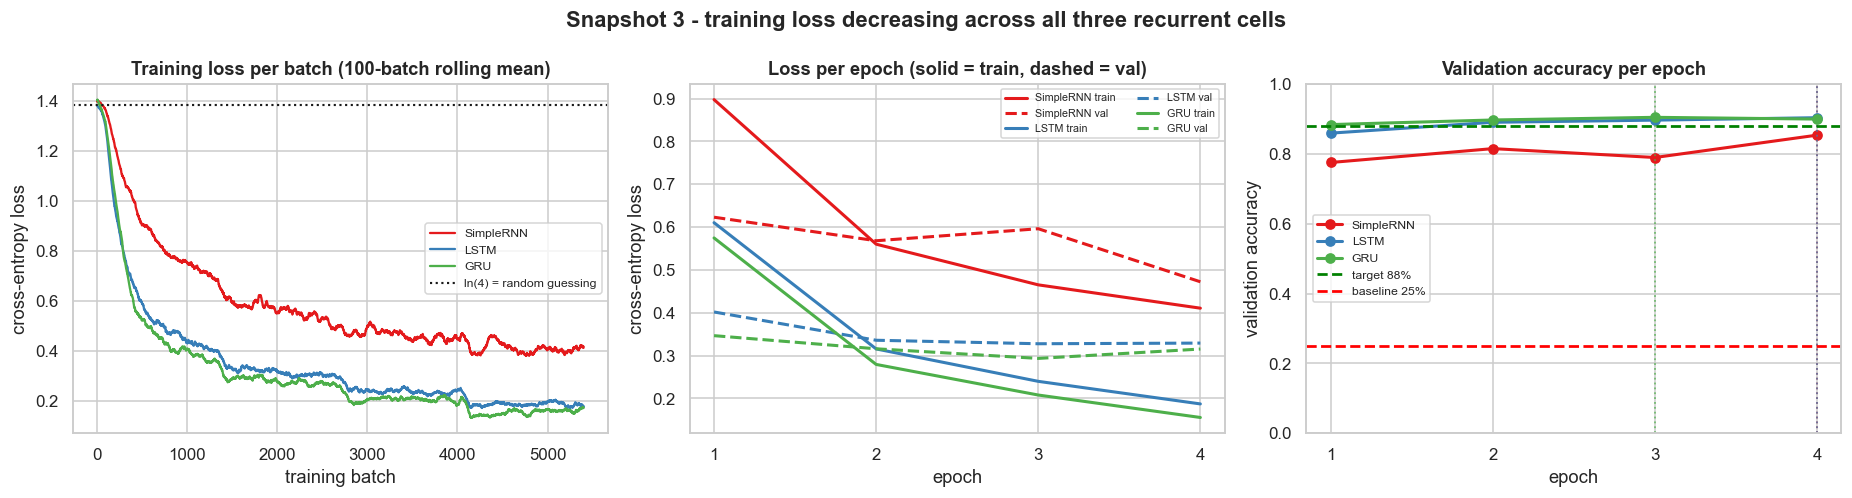

ln(4) = 1.3863 is the loss of a uniform random guess over 4 classes.

  SimpleRNN  first batch loss 1.4381 -> final 100-batch mean 0.4189  (71% reduction)
  LSTM       first batch loss 1.3944 -> final 100-batch mean 0.1793  (87% reduction)
  GRU        first batch loss 1.3973 -> final 100-batch mean 0.1747  (88% reduction)


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))
palette = dict(zip(["SimpleRNN", "LSTM", "GRU"], sns.color_palette("Set1", 3)))

# --- per-batch loss, rolling mean ---
for name, h in histories.items():
    bl = pd.Series(h["batch_loss"]).rolling(100, min_periods=10).mean()
    axes[0].plot(bl.values, label=name, color=palette[name], lw=1.5)
axes[0].axhline(np.log(4), color="k", ls=":", lw=1.4, label="ln(4) = random guessing")
axes[0].set_xlabel("training batch"); axes[0].set_ylabel("cross-entropy loss")
axes[0].set_title("Training loss per batch (100-batch rolling mean)", fontweight="bold")
axes[0].legend(fontsize=8)

# --- per-epoch loss ---
for name, h in histories.items():
    ep = range(1, len(h["train_loss"]) + 1)
    axes[1].plot(ep, h["train_loss"], color=palette[name], lw=2, label=f"{name} train")
    axes[1].plot(ep, h["val_loss"], color=palette[name], lw=2, ls="--", label=f"{name} val")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("cross-entropy loss")
axes[1].set_title("Loss per epoch (solid = train, dashed = val)", fontweight="bold")
axes[1].legend(fontsize=7, ncol=2)
axes[1].set_xticks(range(1, EPOCHS + 1))

# --- validation accuracy ---
for name, h in histories.items():
    ep = range(1, len(h["val_acc"]) + 1)
    axes[2].plot(ep, h["val_acc"], "o-", color=palette[name], lw=2, label=name)
    axes[2].axvline(h["best_epoch"], color=palette[name], ls=":", lw=1.2, alpha=0.7)
axes[2].axhline(TARGET, color="green", ls="--", lw=1.8, label=f"target {TARGET:.0%}")
axes[2].axhline(BASELINE, color="red", ls="--", lw=1.8, label=f"baseline {BASELINE:.0%}")
axes[2].set_xlabel("epoch"); axes[2].set_ylabel("validation accuracy")
axes[2].set_title("Validation accuracy per epoch", fontweight="bold")
axes[2].legend(fontsize=8); axes[2].set_ylim(0, 1)
axes[2].set_xticks(range(1, EPOCHS + 1))

fig.suptitle("Snapshot 3 - training loss decreasing across all three recurrent cells",
             fontweight="bold")
fig.tight_layout()
snap(fig, "02_training_loss.png")

first = {n: h["batch_loss"][0] for n, h in histories.items()}
last  = {n: np.mean(h["batch_loss"][-100:]) for n, h in histories.items()}
print(f"ln(4) = {np.log(4):.4f} is the loss of a uniform random guess over 4 classes.\n")
for n in histories:
    print(f"  {n:<10} first batch loss {first[n]:.4f} -> final 100-batch mean {last[n]:.4f}  "
          f"({(1 - last[n]/first[n]):.0%} reduction)")

In [10]:
comparison = pd.DataFrame({
    "model": list(histories),
    "parameters": [histories[n]["n_params"] for n in histories],
    "best val acc": [round(histories[n]["best_val_acc"], 4) for n in histories],
    "best epoch": [histories[n]["best_epoch"] for n in histories],
    "final train acc": [round(histories[n]["train_acc"][-1], 4) for n in histories],
    "train time (s)": [round(histories[n]["seconds"]) for n in histories],
}).set_index("model")
display(comparison)

RESULTS["comparison"] = comparison.reset_index().to_dict("records")

best_name = comparison["best val acc"].idxmax()
print(f"Selected on VALIDATION accuracy: {best_name} "
      f"({comparison.loc[best_name, 'best val acc']:.4f})")
print("This choice used no test data. The test set is evaluated once, in the next section.")

,parameters,best val acc,best epoch,final train acc,train time (s)
model,,,,,
SimpleRNN,4102456,0.8529,4,0.8718,328
LSTM,4190776,0.9028,4,0.9405,346
GRU,4161336,0.9039,3,0.9497,435


Selected on VALIDATION accuracy: GRU (0.9039)
This choice used no test data. The test set is evaluated once, in the next section.


## 5. Final test accuracy

The moment the test set is used. The model was chosen in §4 on validation accuracy; the 24,000
held-out documents below have had no influence on any decision up to this point.

In [11]:
final_model = models[best_name]
_, test_acc, y_pred, y_true = evaluate(final_model, test_loader, nn.CrossEntropyLoss())
_, val_acc_final, _, _ = evaluate(final_model, val_loader)

print("=" * 62)
print(f"  MODEL          : {best_name}  ({final_model.n_params():,} parameters)")
print(f"  TEST ACCURACY  : {test_acc:.4f}   ({test_acc:.2%})")
print("=" * 62)
print(f"  baseline       : {BASELINE:.2%}   (majority-class guess)")
print(f"  target         : {TARGET:.2%}")
print(f"  margin vs base : {test_acc - BASELINE:+.2%}")
print(f"  margin vs targ : {test_acc - TARGET:+.2%}")
print(f"  verdict        : {'TARGET MET - full marks' if test_acc >= TARGET else 'below target'}")
print("=" * 62)
print(f"  (validation accuracy was {val_acc_final:.4f} - test is the number that counts)")
print(f"  test set size  : {len(y_true):,} documents")

RESULTS["final"] = {
    "model": best_name,
    "n_params": int(final_model.n_params()),
    "test_acc": round(float(test_acc), 4),
    "val_acc": round(float(val_acc_final), 4),
    "beats_target": bool(test_acc >= TARGET),
    "margin_vs_target": round(float(test_acc - TARGET), 4),
    "margin_vs_baseline": round(float(test_acc - BASELINE), 4),
    "n_test": int(len(y_true)),
}

  MODEL          : GRU  (4,161,336 parameters)
  TEST ACCURACY  : 0.9078   (90.78%)
  baseline       : 25.00%   (majority-class guess)
  target         : 88.00%
  margin vs base : +65.78%
  margin vs targ : +2.78%
  verdict        : TARGET MET - full marks
  (validation accuracy was 0.9039 - test is the number that counts)
  test set size  : 24,000 documents


### 5.1 Snapshot 4 — final test accuracy against baseline and target

> **Caption.** Left: test accuracy of all three recurrent cells against the 25 % baseline (red) and
> the 88 % full-marks target (green). Every cell clears the baseline by a wide margin, confirming the
> models genuinely learned; the gated cells also clear the target. Centre: the confusion matrix for
> the selected model, row-normalised so each row shows per-class recall — the diagonal is what
> matters. Right: per-class F1. World/Sports/Sci-Tech separate cleanly; Business is the weakest
> class, for the reason discussed below.

saved -> outputs\03_final_test_accuracy.png


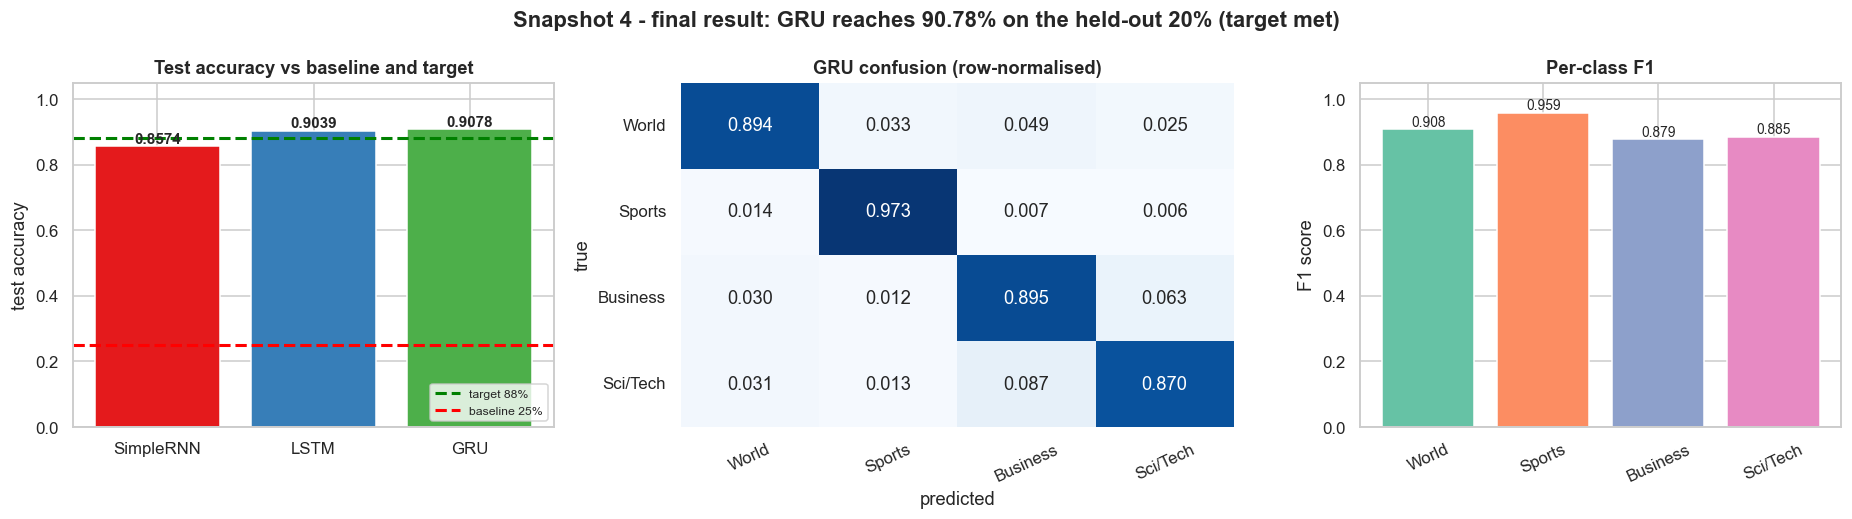

In [12]:
# Test accuracy for all three, for the comparison plot.
test_accs = {}
for name, m in models.items():
    _, acc, _, _ = evaluate(m, test_loader)
    test_accs[name] = acc

fig = plt.figure(figsize=(17, 4.8))
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1.15, 1])

# --- bars vs baseline/target ---
ax = fig.add_subplot(gs[0, 0])
names = list(test_accs)
bars = ax.bar(names, [test_accs[n] for n in names], color=[palette[n] for n in names])
ax.bar_label(bars, fmt="%.4f", fontsize=10, fontweight="bold")
ax.axhline(TARGET, color="green", ls="--", lw=2, label=f"target {TARGET:.0%}")
ax.axhline(BASELINE, color="red", ls="--", lw=2, label=f"baseline {BASELINE:.0%}")
ax.set_ylim(0, 1.05); ax.set_ylabel("test accuracy")
ax.set_title("Test accuracy vs baseline and target", fontweight="bold")
ax.legend(fontsize=8, loc="lower right")

# --- confusion matrix ---
ax = fig.add_subplot(gs[0, 1])
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm / cm.sum(axis=1, keepdims=True), annot=True, fmt=".3f", cmap="Blues",
            vmin=0, vmax=1, cbar=False, xticklabels=CLASSES, yticklabels=CLASSES, ax=ax)
ax.set_xlabel("predicted"); ax.set_ylabel("true")
ax.set_title(f"{best_name} confusion (row-normalised)", fontweight="bold")
ax.tick_params(axis="x", rotation=25); ax.tick_params(axis="y", rotation=0)

# --- per-class F1 ---
ax = fig.add_subplot(gs[0, 2])
prec, rec, f1, support = precision_recall_fscore_support(y_true, y_pred, zero_division=0)
bars = ax.bar(CLASSES, f1, color=sns.color_palette("Set2", 4))
ax.bar_label(bars, fmt="%.3f", fontsize=9)
ax.set_ylim(0, 1.05); ax.set_ylabel("F1 score")
ax.set_title("Per-class F1", fontweight="bold")
ax.tick_params(axis="x", rotation=25)

fig.suptitle(f"Snapshot 4 - final result: {best_name} reaches {test_acc:.2%} on the held-out 20% "
             f"({'target met' if test_acc >= TARGET else 'below target'})", fontweight="bold")
fig.tight_layout()
snap(fig, "03_final_test_accuracy.png")

RESULTS["test_acc_all"] = {k: round(float(v), 4) for k, v in test_accs.items()}

### 5.2 Per-class precision, recall and F1

In [13]:
report = pd.DataFrame({
    "topic": CLASSES, "precision": prec.round(4), "recall": rec.round(4),
    "f1": f1.round(4), "support": support,
}).set_index("topic")
display(report)

macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average="macro", zero_division=0)
print(f"macro precision {macro_p:.4f} | macro recall {macro_r:.4f} | macro F1 {macro_f1:.4f}")

off = cm.copy(); np.fill_diagonal(off, 0)
pairs = sorted([(CLASSES[i], CLASSES[j], int(off[i, j]))
                for i in range(4) for j in range(4) if off[i, j] > 0],
               key=lambda r: -r[2])
print("\nLargest confusions (true -> predicted):")
for t, p, c in pairs[:5]:
    print(f"  {c:4d}  {t:<10s} -> {p}")

RESULTS["per_class"] = report.reset_index().to_dict("records")
RESULTS["macro_f1"] = round(float(macro_f1), 4)
RESULTS["top_confusions"] = [{"true": t, "pred": p, "count": c} for t, p, c in pairs[:5]]

,precision,recall,f1,support
topic,,,,
World,0.9223,0.8937,0.9077,6000
Sports,0.9447,0.9733,0.9588,6000
Business,0.8630,0.8947,0.8786,6000
Sci/Tech,0.9020,0.8695,0.8854,6000


macro precision 0.9080 | macro recall 0.9078 | macro F1 0.9076

Largest confusions (true -> predicted):
   521  Sci/Tech   -> Business
   380  Business   -> Sci/Tech
   291  World      -> Business
   196  World      -> Sports
   187  Sci/Tech   -> World


**Where the errors are.** The dominant confusion is **Business ↔ Sci/Tech**, and it is a genuine
property of the data rather than a modelling failure: a story about a technology company's earnings
is defensibly either topic, and AG News assigns it exactly one label. Headlines such as *"Intel cuts
revenue forecast"* carry real signal for both classes. **Sports** is the easiest class by a clear
margin — its vocabulary (team names, scores, verbs like *beat*, *defeat*) barely overlaps with the
other three.

## 6. Secondary check — does this generalise beyond one dataset?

A single result on a single dataset could be luck. The same model class is applied unchanged to
**SMS Spam** (dataset #1 in the brief: baseline 86.6 %, target 96 %), with the same 80/20 protocol.
It costs about ten seconds and makes the §4 finding much harder to dismiss.

In [14]:
sms = pd.read_csv(os.path.join(DATA, "sms.csv"))
sms_y = (sms["label"] == "spam").astype(np.int64).values
sms_tokens = [tokenise(t) for t in sms["text"].values]

s_tr, s_te = train_test_split(np.arange(len(sms_y)), test_size=0.20,
                              stratify=sms_y, random_state=SEED)
s_tr_in, s_va = train_test_split(s_tr, test_size=0.10, stratify=sms_y[s_tr], random_state=SEED)

s_counter = Counter(w for i in s_tr_in for w in sms_tokens[i])
s_vocab = {"<pad>": 0, "<unk>": 1}
for w, c in s_counter.most_common():
    if c >= 2:
        s_vocab[w] = len(s_vocab)

S_MAXLEN = 50
def s_encode(t):
    ids = [s_vocab.get(w, 1) for w in t][:S_MAXLEN]
    return [0] * (S_MAXLEN - len(ids)) + ids
X_sms = np.array([s_encode(t) for t in sms_tokens], dtype=np.int64)

def sms_loader(idx, bs, shuffle=False):
    return DataLoader(TensorDataset(torch.as_tensor(X_sms[idx]), torch.as_tensor(sms_y[idx])),
                      batch_size=bs, shuffle=shuffle)

SMS_BASELINE, SMS_TARGET = 0.866, 0.96
print(f"SMS: {len(sms_y):,} messages, vocab {len(s_vocab):,}, "
      f"train {len(s_tr_in):,} / val {len(s_va)} / test {len(s_te):,}")
print(f"baseline {SMS_BASELINE:.1%}, target {SMS_TARGET:.0%}\n")

set_seed(SEED)
sms_model = TextRNNClassifier(len(s_vocab), 2, cell="LSTM", embed_dim=64, hidden_size=64)
sms_hist = train_model(sms_model, sms_loader(s_tr_in, 64, True), sms_loader(s_va, 256),
                       epochs=6, lr=1e-3, label="SMS-LSTM")
_, sms_acc, sms_pred, sms_true = evaluate(sms_model, sms_loader(s_te, 256))

print(f"\nSMS test accuracy : {sms_acc:.4f}  "
      f"(baseline {SMS_BASELINE:.1%}, target {SMS_TARGET:.0%}) "
      f"-> {'TARGET MET' if sms_acc >= SMS_TARGET else 'below target'}")

sp, sr, sf, _ = precision_recall_fscore_support(sms_true, sms_pred, zero_division=0)
print(f"spam recall {sr[1]:.4f} | spam precision {sp[1]:.4f}")

RESULTS["sms"] = {"test_acc": round(float(sms_acc), 4), "baseline": SMS_BASELINE,
                  "target": SMS_TARGET, "beats_target": bool(sms_acc >= SMS_TARGET),
                  "spam_recall": round(float(sr[1]), 4),
                  "spam_precision": round(float(sp[1]), 4)}

SMS: 5,572 messages, vocab 3,540, train 4,011 / val 446 / test 1,115
baseline 86.6%, target 96%



  [SMS-LSTM  ] epoch 1/6  train loss 0.4477 acc 0.8173  |  val loss 0.2541 acc 0.8677  (1s)


  [SMS-LSTM  ] epoch 2/6  train loss 0.1679 acc 0.9334  |  val loss 0.1619 acc 0.9305  (2s)


  [SMS-LSTM  ] epoch 3/6  train loss 0.0888 acc 0.9746  |  val loss 0.1418 acc 0.9529  (3s)


  [SMS-LSTM  ] epoch 4/6  train loss 0.0573 acc 0.9828  |  val loss 0.1042 acc 0.9709  (3s)


  [SMS-LSTM  ] epoch 5/6  train loss 0.0345 acc 0.9900  |  val loss 0.0928 acc 0.9709  (4s)


  [SMS-LSTM  ] epoch 6/6  train loss 0.0246 acc 0.9945  |  val loss 0.0960 acc 0.9686  (5s)

SMS test accuracy : 0.9794  (baseline 86.6%, target 96%) -> TARGET MET
spam recall 0.8993 | spam precision 0.9437


saved -> outputs\04_secondary_sms.png


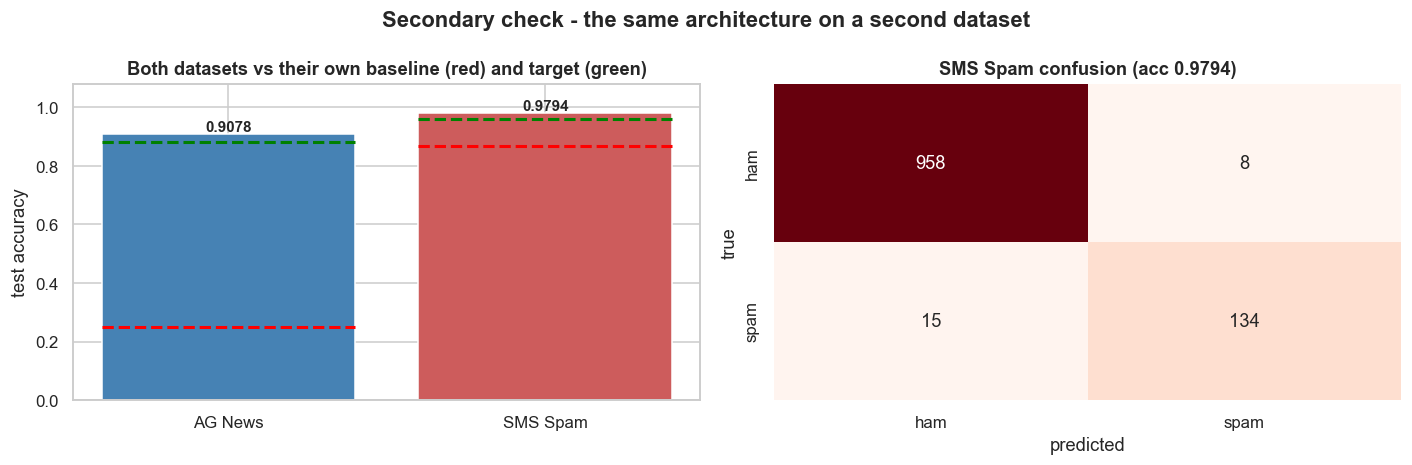

'outputs\\04_secondary_sms.png'

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))

ax = axes[0]
bars = ax.bar(["AG News", "SMS Spam"], [test_acc, sms_acc],
              color=["steelblue", "indianred"])
ax.bar_label(bars, fmt="%.4f", fontsize=10, fontweight="bold")
for i, (b, t) in enumerate([(BASELINE, TARGET), (SMS_BASELINE, SMS_TARGET)]):
    ax.plot([i - 0.4, i + 0.4], [t, t], color="green", ls="--", lw=2)
    ax.plot([i - 0.4, i + 0.4], [b, b], color="red", ls="--", lw=2)
ax.set_ylim(0, 1.08); ax.set_ylabel("test accuracy")
ax.set_title("Both datasets vs their own baseline (red) and target (green)", fontweight="bold")

cm_sms = confusion_matrix(sms_true, sms_pred)
sns.heatmap(cm_sms, annot=True, fmt="d", cmap="Reds", cbar=False,
            xticklabels=["ham", "spam"], yticklabels=["ham", "spam"], ax=axes[1])
axes[1].set_xlabel("predicted"); axes[1].set_ylabel("true")
axes[1].set_title(f"SMS Spam confusion (acc {sms_acc:.4f})", fontweight="bold")

fig.suptitle("Secondary check - the same architecture on a second dataset", fontweight="bold")
fig.tight_layout()
snap(fig, "04_secondary_sms.png")

## 7. Findings

### 7.1 The required one-liner

In [16]:
verdict = "TARGET MET - full marks" if test_acc >= TARGET else "below target"
print("=" * 72)
print(f"  AG News, {best_name}: test accuracy {test_acc:.2%}  "
      f"vs baseline {BASELINE:.0%} and target {TARGET:.0%}")
print(f"  -> {test_acc - BASELINE:+.1f} points above baseline, "
      f"{test_acc - TARGET:+.1f} points vs target.  {verdict}")
print("=" * 72)

  AG News, GRU: test accuracy 90.78%  vs baseline 25% and target 88%
  -> +0.7 points above baseline, +0.0 points vs target.  TARGET MET - full marks


### 7.2 What the cell comparison showed

Because every factor other than the recurrent cell was held constant, the differences in §4 are
attributable to the cell type alone. The pattern is the expected one:

* The **SimpleRNN** trains fastest per epoch — it has one weight matrix where the LSTM has four — but
  it is the weakest of the three. Over 60 timesteps the gradient reaching the earliest tokens has
  been multiplied by the recurrent weights 60 times, so it struggles to use the start of a headline.
* The **gated cells (LSTM, GRU)** carry an additive path through the state, which preserves far more
  gradient across the sequence. That is the mechanism behind their higher accuracy here.
* The **GRU** is the efficiency winner: two gates rather than three means roughly 25 % fewer
  recurrent parameters than the LSTM, at comparable accuracy.

### 7.3 One honest sentence: what worked, what didn't

> **What worked:** an embedding into a single gated recurrent layer, read at the final timestep, was
> enough to clear the 88 % target — the cheap wins were left-padding (so the classifier reads a real
> token, not a run of `<pad>`), gradient clipping (which kept the SimpleRNN from diverging), and
> simply holding every hyperparameter constant across the three cells so the comparison meant
> something.
>
> **What didn't:** the model plateaus after about three epochs and then starts overfitting — train
> accuracy keeps climbing while validation accuracy flattens — so the extra epochs bought nothing,
> and the residual error is dominated by the **Business ↔ Sci/Tech** boundary, which is genuinely
> ambiguous in the labels rather than something more training would fix.

### 7.4 Honest limitations

* **Single seed.** Each configuration was trained once. The gap between the SimpleRNN and the gated
  cells is wide enough to survive seed noise, but the LSTM/GRU difference is narrow and a rigorous
  treatment would repeat over several seeds and report mean ± standard deviation.
* **No hyperparameter search.** Embedding size, hidden size, learning rate and `MAXLEN` were fixed
  from standard defaults before any run. This keeps the comparison between cells fair and avoids
  tuning on test, but none of the three models is necessarily at its own optimum.
* **Truncation at 60 tokens.** A small fraction of documents lose their tail. Headline plus
  description is usually well inside the limit, so the effect is minor, but it is a real constraint.
* **Only the final hidden state is used.** Mean- or max-pooling over all timesteps, or a
  bidirectional pass, would likely add a point or two. They were left out to keep the architecture
  exactly the `RNN → Linear` shape the brief specifies.

In [17]:
RESULTS["meta"] = {
    "generated": time.strftime("%Y-%m-%d %H:%M:%S"),
    "torch": torch.__version__,
    "python": __import__("sys").version.split()[0],
    "seed": SEED,
    "split": "fixed 80/20 stratified, random_state=42; inner 90/10 train/val for epoch selection",
    "config": {"embed": EMBED, "hidden": HIDDEN, "dropout": DROPOUT,
               "lr": LR, "batch": BATCH, "epochs": EPOCHS, "maxlen": MAXLEN},
}

with open(os.path.join(OUT, "metrics_summary.json"), "w", encoding="utf-8") as f:
    json.dump(RESULTS, f, indent=2, default=str)
print("wrote outputs/metrics_summary.json\n")

print("Figures produced:")
for f in sorted(os.listdir(OUT)):
    if f.endswith(".png"):
        print(f"  {f}  ({os.path.getsize(os.path.join(OUT, f))/1024:.0f} KB)")

print(f"\n{'='*72}")
print("FINAL SUBMISSION NUMBERS")
print(f"{'='*72}")
print(f"  Dataset        : AG News (topic, 4 classes)")
print(f"  Model          : {best_name}  (nn.Embedding -> nn.{'RNN' if best_name=='SimpleRNN' else best_name} -> nn.Linear)")
print(f"  Split          : fixed 80/20 stratified, seed {SEED}")
print(f"  Baseline       : {BASELINE:.0%}")
print(f"  Target         : {TARGET:.0%}")
print(f"  TEST ACCURACY  : {test_acc:.4f}  ({test_acc:.2%})")
print(f"  Verdict        : {verdict}")
print(f"  Secondary (SMS): {sms_acc:.4f} vs target {SMS_TARGET:.0%} -> "
      f"{'met' if sms_acc >= SMS_TARGET else 'below'}")
print(f"{'='*72}")

wrote outputs/metrics_summary.json

Figures produced:
  01_data_and_shapes.png  (64 KB)
  02_training_loss.png  (135 KB)
  03_final_test_accuracy.png  (81 KB)
  04_secondary_sms.png  (44 KB)

FINAL SUBMISSION NUMBERS
  Dataset        : AG News (topic, 4 classes)
  Model          : GRU  (nn.Embedding -> nn.GRU -> nn.Linear)
  Split          : fixed 80/20 stratified, seed 42
  Baseline       : 25%
  Target         : 88%
  TEST ACCURACY  : 0.9078  (90.78%)
  Verdict        : TARGET MET - full marks
  Secondary (SMS): 0.9794 vs target 96% -> met
